# Poster – IPA Beispielsätze

In [4]:
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np

CSV       = "Data/transcriptions_clean.csv"
CLIPS_DIR = "Data/clips__test"

df = pd.read_csv(CSV)

# 10 Vorschläge
candidates = df.iloc[:20][['sentence', 'ipa_audio', 'ipa_reference']].copy()
candidates.index = range(20)
print(candidates[['sentence', 'ipa_audio']].to_string())

                                                                                    sentence                                                                             ipa_audio
0                                                        Der Bericht enthält weitere Lücken.                                                        dɛt brɪxt ɛntɦatɛt vitər lyːkə
1                                       Auch die FDP möchte ihre Vertretung weiter ausbauen.                                             aʊ tɛftɪpeː vøːkiːr efɛtɾɛtɪg vitə uspaʊə
2                                    Zudem bin ich bei SRF als Experte noch ein wenig dabei.                              tsuːdɛn biniː biːɛsərɛf als ɛkspɛɾtɛ nɔɾ ɛs piːtslɪdɛbiː
3                                      Dafür wurde er mit der Fields-Medaille ausgezeichnet.                              dɑːrdɛ fyːɾ ɪn ɪn dɛn fiːlt mɪdɛlɾiː aʊstsaɪçnət vɑːrdən
4                                               Das habe ich mir aber nur einmal angeschaut.             

In [5]:
# ← Hier Index wählen (0–9)
ROW_IDX = 13

row = df.iloc[ROW_IDX]
print("Satz:        ", row['sentence'])
print()
print("IPA Aufnahme:", row['ipa_audio'])
print()
print("IPA Referenz:", row['ipa_reference'])

Satz:         Da dürfen wir kein Risiko eingehen.

IPA Aufnahme: tɔːtɔːfɔːmiːɔːk kʰæːj ɾɪːsikɔːiːgɔː

IPA Referenz: dɑː dʏɾfən viːɾ kaɪn riːziːkoː aɪnɡeːən


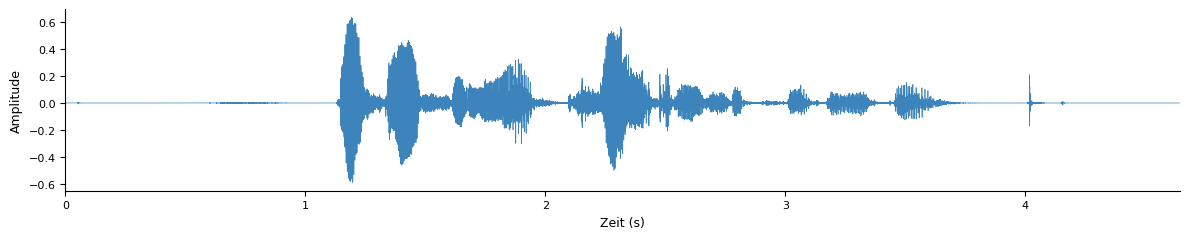

In [6]:
audio_path = f"{CLIPS_DIR}/{row['path']}"
y, sr = librosa.load(audio_path, sr=None)
times = np.linspace(0, len(y) / sr, num=len(y))

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(times, y, color="#1a6faf", linewidth=0.5, alpha=0.85)
ax.set_xlabel("Zeit (s)", fontsize=9)
ax.set_ylabel("Amplitude", fontsize=9)
ax.set_xlim(0, times[-1])
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()